In [1]:
import numpy as np 
import pandas as pd
from pathlib import Path 
from src import utils, db, rsm, behavmatch 
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%load_ext autoreload
%autoreload 2
from matplotlib import rcParams
default_font = 8
fs_title = 10
rcParams['font.size'] = default_font
rcParams['axes.titlesize'] = fs_title
from IPython.display import clear_output

In [2]:
working_dbase = db.get_sessions().query("recording == True")
working_dbase.loc[:, "name_round"] = working_dbase["mname"] + "_"+ working_dbase["round_id"].astype(str)
sessions = working_dbase["session"].unique()
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int'] 
nmice = working_dbase["name_round"].nunique()
nareas = len(areas)
ncelltypes = len(celltype)
n_sessions = len(sessions)

In [3]:
obj_path = Path(r"D:\mouseobj")

In [ ]:
rows = []
for iss, sess in enumerate(sessions):
    d = working_dbase.query(f"session == '{sess}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        mask_B = m.frameselector['trial_type'].isin(['non rewarded', 'non rewarded test'])
        base = m.frameselector['istim'].astype('Int64') - 1  # zero-based
        m.frameselector['stim_id_matrix'] = np.where(~mask_B, base, base + 51)
        ntrials = m.interp_spks.shape[1]
        save_pth = obj_path.joinpath(name,datexp,blk)
        rsm_m = np.empty((ntrials, ntrials, nareas, ncelltypes))
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                print(f"Processing area: {area}, celltype: {ctype}")
                sig_neurons, nneurons = rsm.get_sig_neurons(m, area=area, celltype=ctype, cc_tsh=0.1)
                rsm_matrix = rsm.get_rsm_trial(sig_neurons)
                trials_per_stim = rsm.get_trials_per_stim(m)
                rsm_cleaned = rsm.clean_rsm_trial(rsm_matrix, sig_neurons, trials_per_stim)
                rsm_m[:,:,ia,ic] = rsm_cleaned
                #prot
                filtered_rsm_prot = rsm.filter_rsm(rsm_cleaned, m.trial_dict["rewarded"], m.trial_dict["non rewarded"])
                intraA_prot, intraB_prot, intercat_prot = rsm.compute_iindex_cond(filtered_rsm_prot, m.trial_dict["rewarded"])
                #nonprot
                filtered_rsm_nonprot = rsm.filter_rsm(rsm_cleaned, m.trial_dict["rewarded test"], m.trial_dict["non rewarded test"])
                intraA_nonprot, intraB_nonprot, intercat_nonprot = rsm.compute_iindex_cond(filtered_rsm_nonprot, m.trial_dict["rewarded test"])
                rows.append({
                    "mouse": name,
                    "session": sess,
                    "area": area,
                    "celltype": ctype,
                    "IntraA_prot": intraA_prot,
                    "IntraB_prot": intraB_prot,
                    "InterCat_prot": intercat_prot,
                    "IntraA_nonprot": intraA_nonprot,
                    "IntraB_nonprot": intraB_nonprot,
                    "InterCat_nonprot": intercat_nonprot
                })
        np.save(save_pth.joinpath("trial_trial_rsm.npy"), rsm_m)
    clear_output(wait=True)
df_iindex_trial = pd.DataFrame(rows)
df_iindex_trial.to_csv(obj_path.joinpath("overall","trial_trial_rsm_summary_alltrials.csv"), index=False)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Processing area: V1, celltype: Pyr
Processing area: V1, celltype: Int
Processing area: medial, celltype: Pyr
Processing area: medial, celltype: Int
Processing area: lateral, celltype: Pyr
Processing area: lateral, celltype: Int
Processing area: anterior, celltype: Pyr
Processing area: anterior, celltype: Int
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_va

In [20]:
sig_neurons.shape

(53, 399)

(array([[ 2., 39., 10., ...,  0.,  0.,  0.],
        [ 6., 32., 14., ...,  0.,  0.,  0.],
        [ 2., 36., 13., ...,  0.,  0.,  0.],
        ...,
        [ 4., 32., 11., ...,  0.,  0.,  0.],
        [ 0., 37., 14., ...,  0.,  0.,  0.],
        [ 4., 34., 13., ...,  0.,  0.,  0.]], shape=(399, 10)),
 array([-2.57709427, -1.26322569,  0.05064288,  1.36451146,  2.67838004,
         3.99224862,  5.30611719,  6.61998577,  7.93385435,  9.24772293,
        10.5615915 ]),
 <a list of 399 BarContainer objects>)

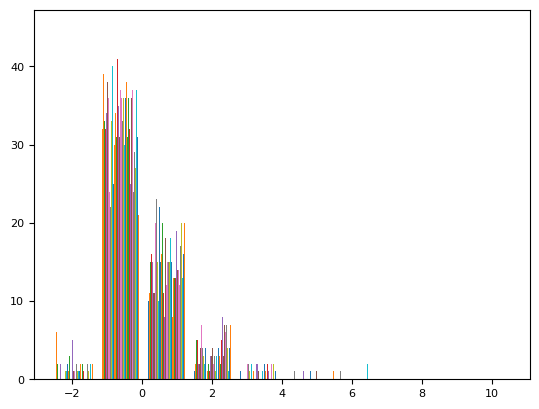

In [19]:
plt.hist(sig_neurons)

In [32]:
sess

'all rewarded after'

In [35]:
working_dbase.query(f"session == '{sessions[2]}'")

,mname,datexp,blk,session,round_id,recording,obj,name_round
2,VG11,2024_10_31,2,last training,1,True,old,VG11_1
6,VG11,2024_11_14,2,last training,2,True,old,VG11_2
10,VG14,2024_11_21,2,last training,1,True,old,VG14_1
14,VG15,2024_10_31,2,last training,1,True,old,VG15_1
18,VG21,2025_07_17,3,last training,1,True,old,VG21_1
22,VG21,2025_08_07,2,last training,2,True,old,VG21_2
26,VG24,2025_07_10,2,last training,1,True,old,VG24_1
30,VG33,2025_10_09,3,last training,1,True,old,VG33_1
34,VG34,2025_10_10,3,last training,1,True,old,VG34_1
38,VGa9,2025_11_20,2,last training,1,True,new,VGa9_1


In [47]:
probs = np.load(r"D:\mouseobj\overall\last_training\overall_probs.npy", allow_pickle=True)

In [5]:
rows = []
d = working_dbase.query(f"session == '{sessions[2]}'")
cbin = 3 # each bin is cummaltive of :25 , bin = 3 -> 100 cm in the corridor
print(f"Processing: {sessions[2]}")
for i, (_, row) in enumerate(d.iterrows()):
    name, datexp, blk = row["mname"], row["datexp"], row["blk"]
    m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
    mask_B = m.frameselector['trial_type'].isin(['non rewarded', 'non rewarded test'])
    base = m.frameselector['istim'].astype('Int64') - 1  # zero-based
    m.frameselector['stim_id_matrix'] = np.where(~mask_B, base, base + 51)
    ntrials = m.interp_spks.shape[1]
    save_pth = obj_path.joinpath(name,datexp,blk)
    protA = m.trial_dict["rewarded"]
    protB = m.trial_dict["non rewarded"]
    restA = m.trial_dict["rewarded test"]
    restB =  m.trial_dict["non rewarded test"]
    rsm_m = np.load(save_pth.joinpath("trial_trial_rsm.npy"))
    probs = np.load(save_pth.joinpath("probs.npy"), allow_pickle=True)
    prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
    rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
    m_rew = np.concatenate(prot_matched_trials[:,0]).astype(int)
    m_nrew = np.concatenate(prot_matched_trials[:,1]).astype(int)
    m_rew_test = np.concatenate(rest_matched_trials[:,0]).astype(int)
    m_nrew_test = np.concatenate(rest_matched_trials[:,1]).astype(int)
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            print(f"Processing area: {area}, celltype: {ctype}")
            rsm_m_layer = rsm_m[:,:,ia,ic]
            #prot
            filtered_rsm_prot = rsm.filter_rsm(rsm_m_layer, m_rew, m_nrew)
            intraA_prot, intraB_prot, intercat_prot = rsm.compute_iindex_cond(filtered_rsm_prot, m_rew)
            #nonprot
            filtered_rsm_nonprot = rsm.filter_rsm(rsm_m_layer, m_rew_test, m_nrew_test)
            intraA_nonprot, intraB_nonprot, intercat_nonprot = rsm.compute_iindex_cond(filtered_rsm_nonprot, m_rew_test)
            rows.append({
                "mouse": name,
                "session": "last training (matched)",
                "area": area,
                "celltype": ctype,
                "IntraA_prot": intraA_prot,
                "IntraB_prot": intraB_prot,
                "InterCat_prot": intercat_prot,
                "IntraA_nonprot": intraA_nonprot,
                "IntraB_nonprot": intraB_nonprot,
                "InterCat_nonprot": intercat_nonprot
            })
clear_output(wait=True)
df_iindex_trial_matched = pd.DataFrame(rows)
df_iindex_trial_matched.to_csv(obj_path.joinpath("overall","last_training","trial_trial_rsm_summary_matched.csv"), index=False)

Processing: last training
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_10_31\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Processing area: V1, celltype: Pyr
Processing area: V1, celltype: Int
Processing area: medial, celltype: Pyr
Processing area: medial, celltype: Int
Processing area: lateral, celltype: Pyr
Processing area: lateral, celltype: Int
Processing area: anterior, celltype: Pyr
Processing area: anterior, celltype: Int
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '

In [6]:
df_iindex_trial = df_iindex_trial.assign(invariance_prot = np.mean([df_iindex_trial['IntraA_prot'], df_iindex_trial['IntraB_prot']], axis=0)- df_iindex_trial['InterCat_prot'],
                        invariance_nonprot = np.mean([df_iindex_trial['IntraA_nonprot'], df_iindex_trial['IntraB_nonprot']], axis=0) - df_iindex_trial['InterCat_nonprot'])
df_iindex_trial

,mouse,session,area,celltype,IntraA_prot,IntraB_prot,InterCat_prot,IntraA_nonprot,IntraB_nonprot,InterCat_nonprot,invariance_prot,invariance_nonprot
0,VG11,all rewarded before,V1,Pyr,0.219642,0.190431,-0.117548,0.044980,0.041535,0.003284,0.322585,0.039974
1,VG11,all rewarded before,V1,Int,0.208943,0.119765,-0.049830,0.056518,0.066701,0.039676,0.214184,0.021934
2,VG11,all rewarded before,medial,Pyr,0.154004,0.141455,-0.088136,0.041765,0.036376,0.001231,0.235866,0.037840
3,VG11,all rewarded before,medial,Int,0.075134,0.171422,-0.057195,0.038841,0.038577,0.023316,0.180473,0.015394
4,VG11,all rewarded before,lateral,Pyr,0.234195,0.210595,-0.135326,0.050929,0.047713,-0.006638,0.357721,0.055959
...,...,...,...,...,...,...,...,...,...,...,...,...
307,VGa9,all rewarded after,medial,Int,0.205674,0.194523,-0.043017,0.114728,0.093307,-0.039540,0.243115,0.143557
308,VGa9,all rewarded after,lateral,Pyr,0.252422,0.204811,-0.091998,0.059334,0.042590,-0.021618,0.320615,0.072580
309,VGa9,all rewarded after,lateral,Int,0.273220,0.218249,-0.072724,0.064783,0.057874,-0.013198,0.318459,0.074526
310,VGa9,all rewarded after,anterior,Pyr,0.137582,0.114140,-0.041926,0.033150,0.052806,-0.014620,0.167788,0.057598


In [7]:
df_iindex_trial

,mouse,session,area,celltype,IntraA_prot,IntraB_prot,InterCat_prot,IntraA_nonprot,IntraB_nonprot,InterCat_nonprot,invariance_prot,invariance_nonprot
0,VG11,all rewarded before,V1,Pyr,0.219642,0.190431,-0.117548,0.044980,0.041535,0.003284,0.322585,0.039974
1,VG11,all rewarded before,V1,Int,0.208943,0.119765,-0.049830,0.056518,0.066701,0.039676,0.214184,0.021934
2,VG11,all rewarded before,medial,Pyr,0.154004,0.141455,-0.088136,0.041765,0.036376,0.001231,0.235866,0.037840
3,VG11,all rewarded before,medial,Int,0.075134,0.171422,-0.057195,0.038841,0.038577,0.023316,0.180473,0.015394
4,VG11,all rewarded before,lateral,Pyr,0.234195,0.210595,-0.135326,0.050929,0.047713,-0.006638,0.357721,0.055959
...,...,...,...,...,...,...,...,...,...,...,...,...
307,VGa9,all rewarded after,medial,Int,0.205674,0.194523,-0.043017,0.114728,0.093307,-0.039540,0.243115,0.143557
308,VGa9,all rewarded after,lateral,Pyr,0.252422,0.204811,-0.091998,0.059334,0.042590,-0.021618,0.320615,0.072580
309,VGa9,all rewarded after,lateral,Int,0.273220,0.218249,-0.072724,0.064783,0.057874,-0.013198,0.318459,0.074526
310,VGa9,all rewarded after,anterior,Pyr,0.137582,0.114140,-0.041926,0.033150,0.052806,-0.014620,0.167788,0.057598


In [8]:
df_iindex_trial_matched = df_iindex_trial_matched.assign(invariance_prot = np.mean([df_iindex_trial_matched['IntraA_prot'], df_iindex_trial_matched['IntraB_prot']], axis=0) - df_iindex_trial_matched['InterCat_prot'],
                        invariance_nonprot = np.mean([df_iindex_trial_matched['IntraA_nonprot'], df_iindex_trial_matched['IntraB_nonprot']], axis=0) - df_iindex_trial_matched['InterCat_nonprot'])
df_iindex_trial_matched

,mouse,session,area,celltype,IntraA_prot,IntraB_prot,InterCat_prot,IntraA_nonprot,IntraB_nonprot,InterCat_nonprot,invariance_prot,invariance_nonprot
0,VG11,last training (matched),V1,Pyr,0.197760,0.199913,-0.127346,0.038805,0.043324,-0.007109,0.326182,0.048174
1,VG11,last training (matched),V1,Int,0.090378,0.112315,-0.055562,0.034722,0.053727,-0.006472,0.156909,0.050696
2,VG11,last training (matched),medial,Pyr,0.047607,0.066740,-0.044410,0.026292,0.032010,-0.012119,0.101584,0.041270
3,VG11,last training (matched),medial,Int,0.028841,0.079896,-0.045605,0.016415,0.033760,-0.026946,0.099973,0.052033
4,VG11,last training (matched),lateral,Pyr,0.145326,0.186079,-0.112350,0.024829,0.036281,-0.009073,0.278053,0.039628
...,...,...,...,...,...,...,...,...,...,...,...,...
75,VGa9,last training (matched),medial,Int,0.264577,0.280003,-0.092199,0.145953,0.218026,-0.017456,0.364489,0.199445
76,VGa9,last training (matched),lateral,Pyr,0.239492,0.238610,-0.105071,0.061933,0.074089,-0.009105,0.344122,0.077116
77,VGa9,last training (matched),lateral,Int,0.327578,0.244686,-0.116188,0.072227,0.137931,-0.000790,0.402320,0.105869
78,VGa9,last training (matched),anterior,Pyr,0.176300,0.127840,-0.061498,0.035838,0.102274,-0.025604,0.213568,0.094660


In [9]:
concatenated_df = pd.concat([df_iindex_trial, df_iindex_trial_matched], ignore_index=True)
concatenated_df

,mouse,session,area,celltype,IntraA_prot,IntraB_prot,InterCat_prot,IntraA_nonprot,IntraB_nonprot,InterCat_nonprot,invariance_prot,invariance_nonprot
0,VG11,all rewarded before,V1,Pyr,0.219642,0.190431,-0.117548,0.044980,0.041535,0.003284,0.322585,0.039974
1,VG11,all rewarded before,V1,Int,0.208943,0.119765,-0.049830,0.056518,0.066701,0.039676,0.214184,0.021934
2,VG11,all rewarded before,medial,Pyr,0.154004,0.141455,-0.088136,0.041765,0.036376,0.001231,0.235866,0.037840
3,VG11,all rewarded before,medial,Int,0.075134,0.171422,-0.057195,0.038841,0.038577,0.023316,0.180473,0.015394
4,VG11,all rewarded before,lateral,Pyr,0.234195,0.210595,-0.135326,0.050929,0.047713,-0.006638,0.357721,0.055959
...,...,...,...,...,...,...,...,...,...,...,...,...
387,VGa9,last training (matched),medial,Int,0.264577,0.280003,-0.092199,0.145953,0.218026,-0.017456,0.364489,0.199445
388,VGa9,last training (matched),lateral,Pyr,0.239492,0.238610,-0.105071,0.061933,0.074089,-0.009105,0.344122,0.077116
389,VGa9,last training (matched),lateral,Int,0.327578,0.244686,-0.116188,0.072227,0.137931,-0.000790,0.402320,0.105869
390,VGa9,last training (matched),anterior,Pyr,0.176300,0.127840,-0.061498,0.035838,0.102274,-0.025604,0.213568,0.094660


In [10]:
def get_invariance(df: pd.DataFrame, area: str, celltype: str, session: str) -> tuple[np.ndarray, np.ndarray]:
    a = df.query(f"session == '{session}'")
    b = a.query(f"area == '{area}' & celltype == '{celltype}'")
    invariance_values_prot = b['invariance_prot'].values
    invariance_values_nonprot = b['invariance_nonprot'].values
    return invariance_values_prot, invariance_values_nonprot

In [11]:
sessions = ['first training', 'last training', 'last training (matched)']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
nmice = 10
invariances_prot = {}
invariances_nonprot = {}
for sess in sessions: 
    inv_index_prot = np.empty((nmice, len(areas), len(celltype)))
    inv_index_nonprot = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv_prot, inv_nonprot = get_invariance(concatenated_df, area, ctype, sess)
            #store values
            inv_index_prot[:,ia,ic] = inv_prot
            inv_index_nonprot[:,ia,ic] = inv_nonprot
    invariances_prot[sess] = inv_index_prot
    invariances_nonprot[sess] = inv_index_nonprot


# Prototypes

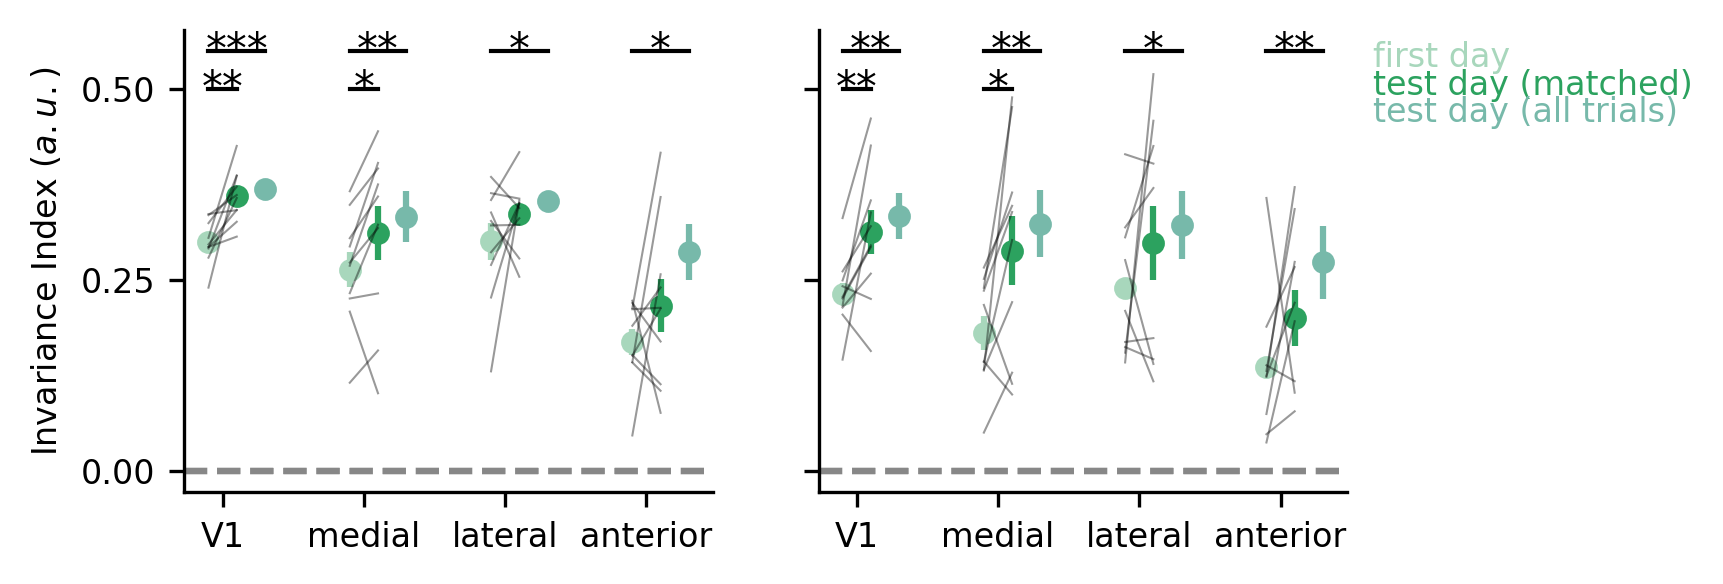

In [12]:

from src import fig1
gis_first = invariances_prot['first training']
gis_last = invariances_prot['last training']
gis_last_m = invariances_prot['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.5, sig_line_control=.55)
sns.despine()

# Non prototypes

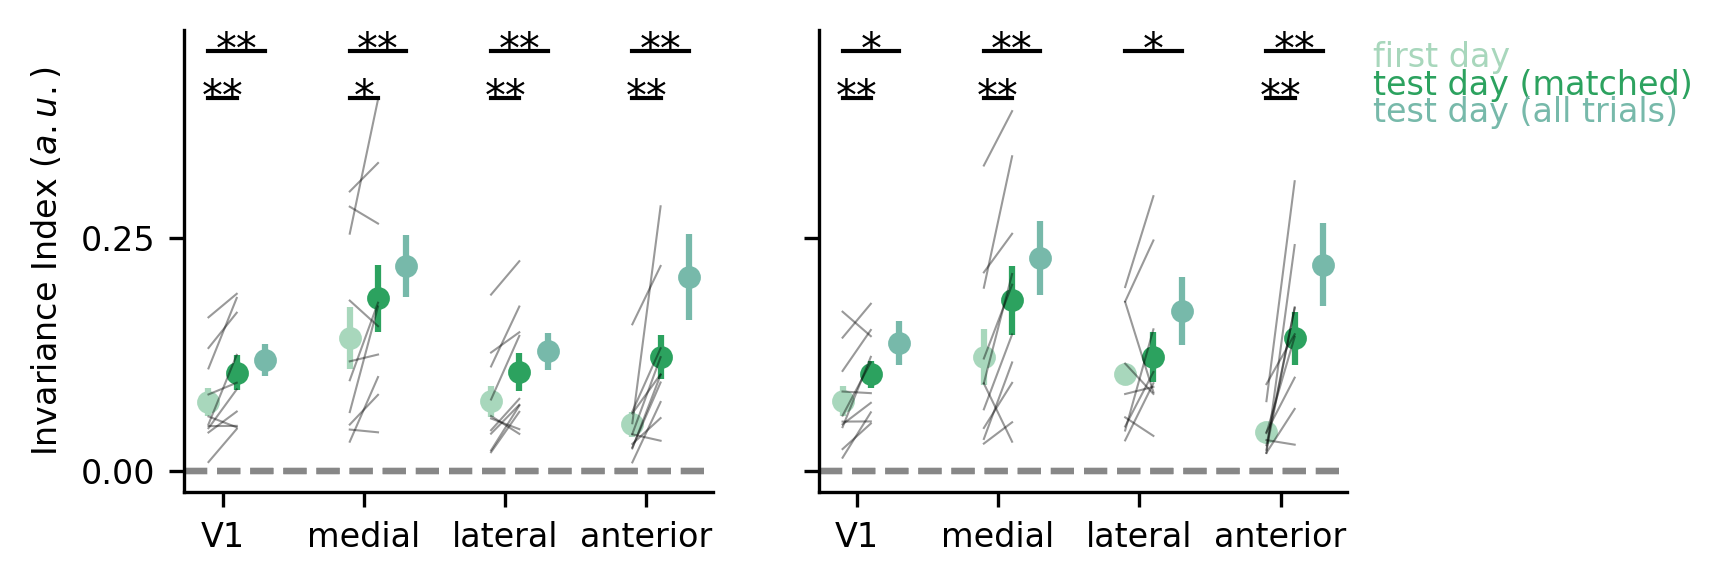

In [13]:
from src import fig1
gis_first = invariances_nonprot['first training']
gis_last = invariances_nonprot['last training']
gis_last_m = invariances_nonprot['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.4, sig_line_control=.45)
sns.despine()

In [14]:
df_no34 = concatenated_df.query("mouse != 'VG34'") #we don't have the all rew after 

In [15]:
sessions = ['all rewarded before', 'all rewarded after']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
nmice = 9 # only 9 sessions
for sess in sessions: 
    inv_index_prot = np.empty((nmice, len(areas), len(celltype)))
    inv_index_nonprot = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv_prot, inv_nonprot = get_invariance(df_no34, area, ctype, sess)
            inv_index_prot[:,ia,ic] = inv_prot
            inv_index_nonprot[:,ia,ic] = inv_nonprot
    invariances_prot[sess] = inv_index_prot
    invariances_nonprot[sess] = inv_index_nonprot

# all water days

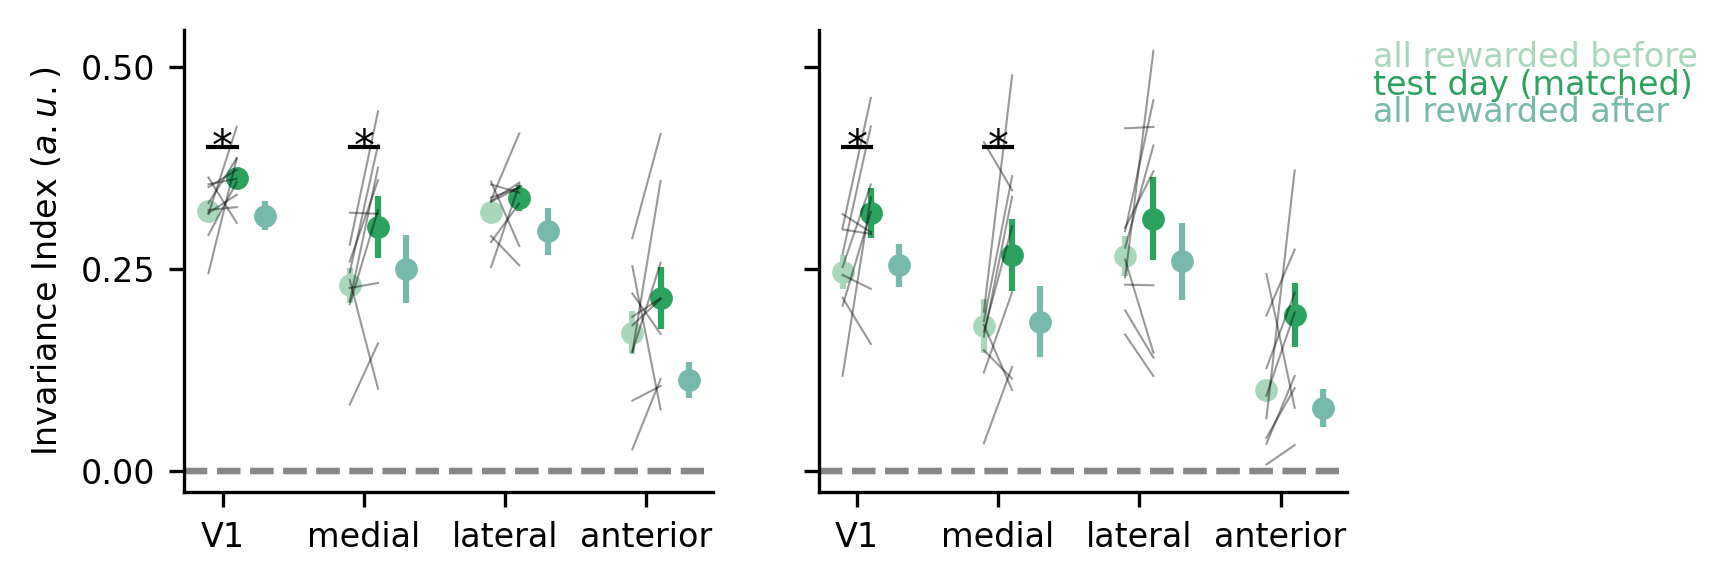

In [16]:

gis_first = invariances_prot['all rewarded before']
gis_last = invariances_prot['all rewarded after']
gis_last_m = np.delete(invariances_prot['last training (matched)'], 8, axis=0)
fig, ax = plt.subplots(1,2, figsize=(5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.4, sig_line_control=.45, labels=["all rewarded before", "test day (matched)", "all rewarded after"])
sns.despine()

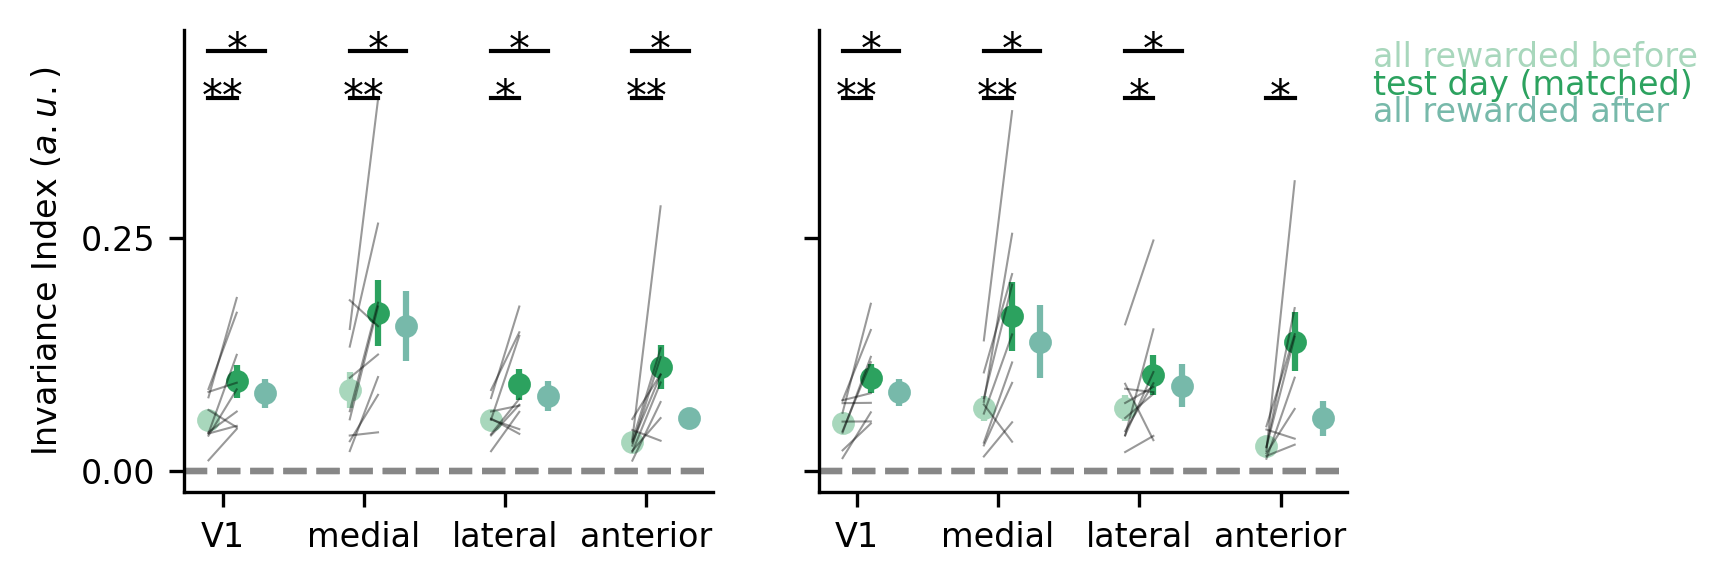

In [17]:
gis_first = invariances_nonprot['all rewarded before']
gis_last = invariances_nonprot['all rewarded after']
gis_last_m = np.delete(invariances_nonprot['last training (matched)'], 8, axis=0)
fig, ax = plt.subplots(1,2, figsize=(5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.4, sig_line_control=.45, labels=["all rewarded before", "test day (matched)", "all rewarded after"])
sns.despine()

In [215]:
from src import rsm 

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGa9\2025_11_06\4
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])


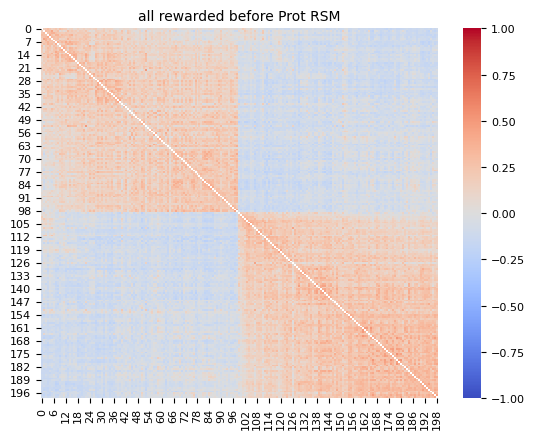

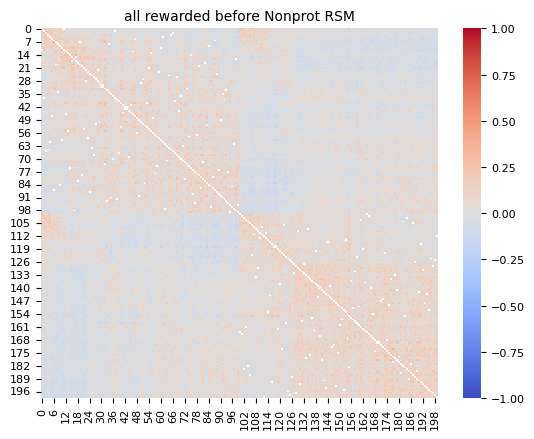

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGa9\2025_11_07\3
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'interp_spks', 'train_dp', 'trial_dict'])


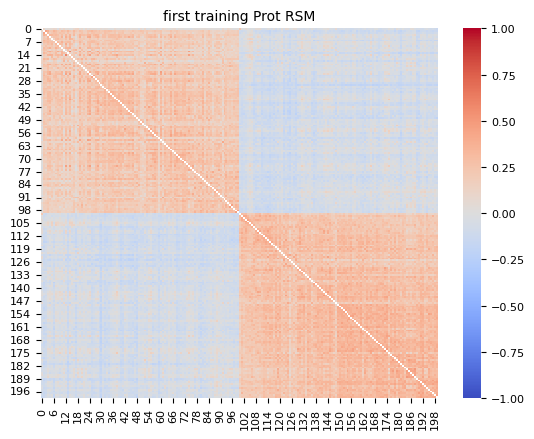

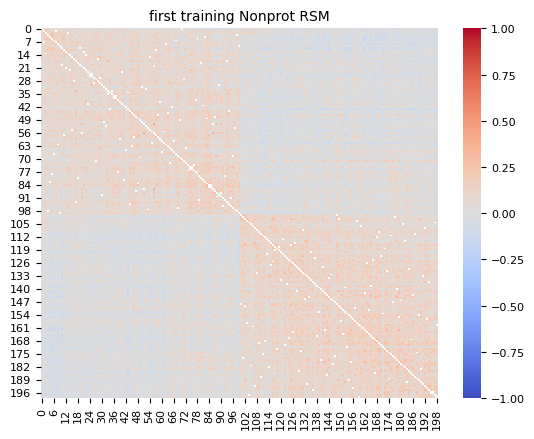

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGa9\2025_11_20\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])


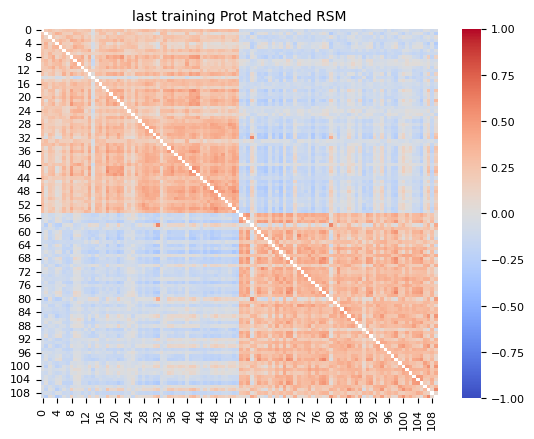

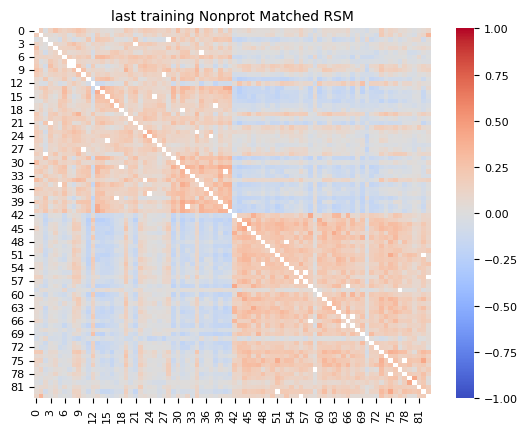

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGa9\2025_11_21\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])


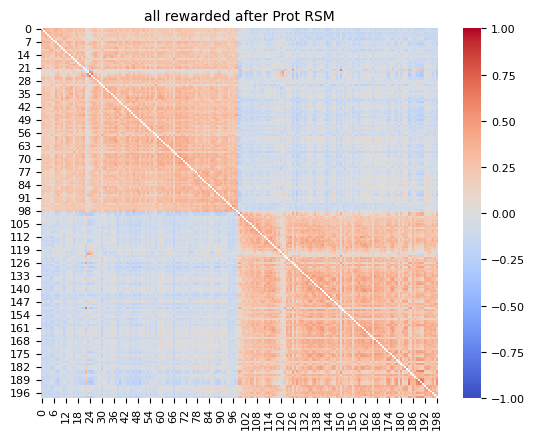

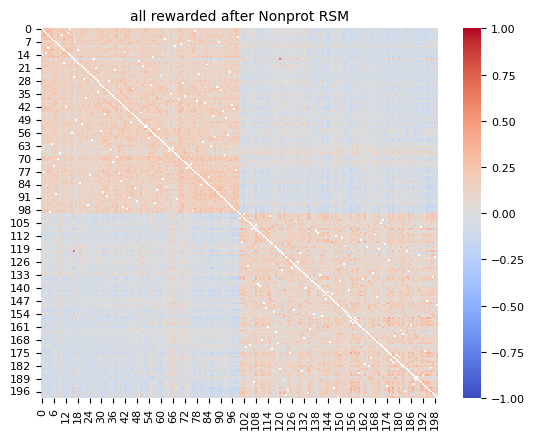

In [219]:
vga9 = working_dbase.query("mname == 'VGa9'")
for i, row in vga9.iterrows():
    m = utils.load_mouse(row["mname"], row["datexp"], row["blk"], load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
    save_path = obj_path.joinpath(row["mname"], row["datexp"], row["blk"])
    rsm_m = np.load(save_path.joinpath("trial_trial_rsm.npy"))
    rsm_m = rsm_m[:,:,1,0]
    if row["session"] == 'last training':
        cbin = 3
        probs = np.load(save_path.joinpath("probs.npy"), allow_pickle=True)
        protA = m.trial_dict["rewarded"]
        protB = m.trial_dict["non rewarded"]
        restA = m.trial_dict["rewarded test"]
        restB =  m.trial_dict["non rewarded test"]
        prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
        rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
        m_rew = np.concatenate(prot_matched_trials[:,0]).astype(int)
        m_nrew = np.concatenate(prot_matched_trials[:,1]).astype(int)
        m_rew_test = np.concatenate(rest_matched_trials[:,0]).astype(int)
        m_nrew_test = np.concatenate(rest_matched_trials[:,1]).astype(int)
        #prot
        filtered_rsm_prot = rsm.filter_rsm(rsm_m, m_rew, m_nrew)
        sns.heatmap(filtered_rsm_prot, cmap='coolwarm', center=0, vmin=-1, vmax=1)
        plt.title(f'{row["session"]} Prot Matched RSM')
        plt.show()
            #nonprot
        filtered_rsm_nonprot = rsm.filter_rsm(rsm_m, m_rew_test, m_nrew_test)
        sns.heatmap(filtered_rsm_nonprot, cmap='coolwarm', center=0, vmin=-1, vmax=1)
        plt.title(f'{row["session"]} Nonprot Matched RSM')
        plt.show()
    else:
        protA = m.trial_dict["rewarded"]
        protB = m.trial_dict["non rewarded"]
        restA = m.trial_dict["rewarded test"]
        restB =  m.trial_dict["non rewarded test"]
        #prot
        filtered_rsm_prot = rsm.filter_rsm(rsm_m, protA, protB)
        sns.heatmap(filtered_rsm_prot, cmap='coolwarm', center=0, vmin=-1, vmax=1)
        plt.title(f'{row["session"]} Prot RSM')
        plt.show()
        #nonprot
        filtered_rsm_nonprot = rsm.filter_rsm(rsm_m, restA, restB)
        sns.heatmap(filtered_rsm_nonprot, cmap='coolwarm', center=0, vmin=-1, vmax=1)
        plt.title(f'{row["session"]} Nonprot RSM')
        plt.show()

# Now we want to explore the rsm structure if we filter by different sig corr quantiles 

In [ ]:
def get_sig_neurons_bins(m, cc, area: str, celltype: str, cc_tsh: tuple = (.95, 1)) -> np.ndarray:
    selection, _ = rsm.filter_neurons(m, area, celltype)
    # ensure column exists (zero-based, as created above)
    if 'stim_id_matrix' not in m.frameselector.columns:
        mask_B = m.frameselector['trial_type'].isin(['non rewarded', 'non rewarded test'])
        base = m.frameselector['istim'].astype('Int64') - 1  # zero-based
        m.frameselector['stim_id_matrix'] =np.where(~mask_B, base, base + 51)
    per_trial_resp = m.interp_spks[:, :, :100].mean(2)  # (neurons, trials)
    # per-trial response over first 100 positions
    per_trial_resp = per_trial_resp[selection, :]  # filter neurons
    cc_region = cc[selection]
    qt = np.quantile(cc_region, [cc_tsh[0], cc_tsh[1]])
    var_condition = (cc_region >= qt[0]) * (cc_region < qt[1])
    sig_neurons = per_trial_resp[var_condition]
    nneurons = sig_neurons.shape[0]
    sig_neurons = zscore(sig_neurons, axis=1, nan_policy='omit') #across textures
    return sig_neurons, nneurons

def get_sig_variance(m) -> np.ndarray:
    per_trial_resp = m.interp_spks[:, :, :100].mean(2)  # (neurons, trials)
    # get stim ids
    stim_ids = []
    for tn in m.frameselector['trial_no'].unique():
        stim_ids.append(m.frameselector.loc[m.frameselector['trial_no'] == tn, 'stim_id_matrix'].values[0])
    stim_ids = np.array(stim_ids)
    cc = rsm.sig_variance(per_trial_resp, stim_ids)
    return cc

In [95]:
working_dbase = db.get_sessions().query("recording == True")
working_dbase.loc[:, "name_round"] = working_dbase["mname"] + "_"+ working_dbase["round_id"].astype(str)
sessions = working_dbase["session"].unique()
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int'] 
nmice = working_dbase["name_round"].nunique()
nareas = len(areas)
ncelltypes = len(celltype)
n_sessions = len(sessions)

In [96]:
sessions

array(['all rewarded before', 'first training', 'last training',
       'all rewarded after'], dtype=object)

In [127]:
var_bins = [(0.55, 0.70), (0.70, 0.85), (0.85, 1.0)]
for iss, sess in enumerate(sessions):
    d = working_dbase.query(f"session == '{sess}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        mask_B = m.frameselector['trial_type'].isin(['non rewarded', 'non rewarded test'])
        base = m.frameselector['istim'].astype('Int64') - 1  # zero-based
        m.frameselector['stim_id_matrix'] = np.where(~mask_B, base, base + 51)
        ntrials = m.interp_spks.shape[1]
        save_pth = obj_path.joinpath(name,datexp,blk)
        rsm_m_bins = np.empty((ntrials, ntrials, len(var_bins), nareas, ncelltypes))
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                print(f"Processing area: {area}, celltype: {ctype}")
                for itsh, cc_tsh in enumerate(var_bins):
                    print(f"Processing bin: {cc_tsh}", end=" ")
                    sig_neurons, nneurons = get_sig_neurons_bins(m, area=area, celltype=ctype, cc_tsh=cc_tsh)
                    rsm_matrix = rsm.get_rsm_trial(sig_neurons)
                    trials_per_stim = rsm.get_trials_per_stim(m)
                    rsm_cleaned = rsm.clean_rsm_trial(rsm_matrix, sig_neurons, trials_per_stim)
                    rsm_m_bins[:,:,itsh,ia,ic] = rsm_cleaned
        np.save(save_pth.joinpath("trial_trial_rsm_bybins.npy"), rsm_m_bins)
    clear_output(wait=True)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Processing area: V1, celltype: Pyr
Processing bin: (0.55, 0.7) Processing bin: (0.7, 0.85) Processing bin: (0.85, 1.0) Processing area: V1, celltype: Int
Processing bin: (0.55, 0.7) Processing bin: (0.7, 0.85) Processing bin: (0.85, 1.0) Processing area: medial, celltype: Pyr
Processing bin: (0.55, 0.7) Processing bin: (0.7, 0.85) Processing bin: (0.85, 1.0) Processing area: medial, celltype: Int
Processing bin: (0.55, 0.7) Processing bin: (0.7, 0.85) Processing bin: (0.85, 1.0) Processing area: lateral, celltype: Pyr
P

<Axes: >

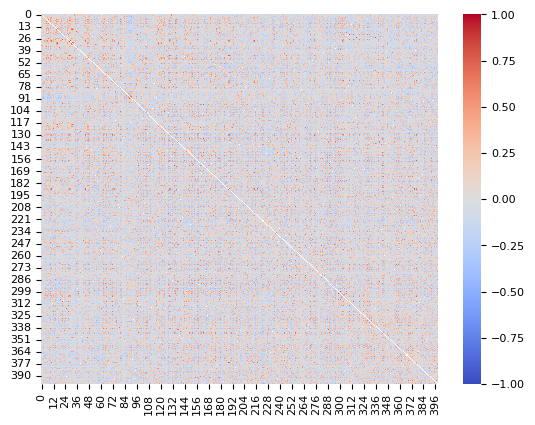

In [143]:
sns.heatmap(rsm_m_bins[:,:,0,0,1], cmap='coolwarm', center=0, vmin=-1, vmax=1)

In [146]:
sessions_names = ['all rewarded before', 'first training', 'last training', 'last training (matched)' ,'all rewarded after']

In [144]:
var_bins

[(0.55, 0.7), (0.7, 0.85), (0.85, 1.0)]

In [148]:
rows = []
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    cbin = 3 # each bin is cummaltive of :25 , bin = 3 -> 100 cm in the corridor
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        save_pth = obj_path.joinpath(name,datexp,blk)
        rsm_m = np.load(save_pth.joinpath("trial_trial_rsm_bybins.npy"))
        if sess == 'last training (matched)':
            probs = np.load(save_pth.joinpath("probs.npy"), allow_pickle=True)
            protA = m.trial_dict["rewarded"]
            protB = m.trial_dict["non rewarded"]
            restA = m.trial_dict["rewarded test"]
            restB =  m.trial_dict["non rewarded test"]
            prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
            rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
            m_rew = np.concatenate(prot_matched_trials[:,0]).astype(int)
            m_nrew = np.concatenate(prot_matched_trials[:,1]).astype(int)
            m_rew_test = np.concatenate(rest_matched_trials[:,0]).astype(int)
            m_nrew_test = np.concatenate(rest_matched_trials[:,1]).astype(int)
        else:
            m_rew, m_nrew, m_rew_test, m_nrew_test = m.trial_dict["rewarded"], m.trial_dict["non rewarded"], m.trial_dict["rewarded test"], m.trial_dict["non rewarded test"]
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                print(f"Processing area: {area}, celltype: {ctype}")
                for itsh, cc_tsh in enumerate(var_bins):
                    rsm_m_layer = rsm_m[:,:,itsh,ia,ic]
                    #prot
                    filtered_rsm_prot = rsm.filter_rsm(rsm_m_layer, m_rew, m_nrew)
                    intraA_prot, intraB_prot, intercat_prot = rsm.compute_iindex_cond(filtered_rsm_prot, m_rew)
                    #nonprot
                    filtered_rsm_nonprot = rsm.filter_rsm(rsm_m_layer, m_rew_test, m_nrew_test)
                    intraA_nonprot, intraB_nonprot, intercat_nonprot = rsm.compute_iindex_cond(filtered_rsm_nonprot, m_rew_test)
                    rows.append({
                        "mouse": name,
                        "session": sess,
                        "area": area,
                        "celltype": ctype,
                        "sig_var": itsh,
                        "IntraA_prot": intraA_prot,
                        "IntraB_prot": intraB_prot,
                        "InterCat_prot": intercat_prot,
                        "IntraA_nonprot": intraA_nonprot,
                        "IntraB_nonprot": intraB_nonprot,
                        "InterCat_nonprot": intercat_nonprot
                    })
    clear_output(wait=True)
df_iindex_trial_bybins = pd.DataFrame(rows)
df_iindex_trial_bybins.to_csv(obj_path.joinpath("overall","trial_trial_rsm_summary_bybins.csv"), index=False)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Processing area: V1, celltype: Pyr
Processing area: V1, celltype: Int
Processing area: medial, celltype: Pyr
Processing area: medial, celltype: Int
Processing area: lateral, celltype: Pyr
Processing area: lateral, celltype: Int
Processing area: anterior, celltype: Pyr
Processing area: anterior, celltype: Int
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_va

In [149]:
df_iindex_trial_bybins

,mouse,session,area,celltype,sig_var,IntraA_prot,IntraB_prot,InterCat_prot,IntraA_nonprot,IntraB_nonprot,InterCat_nonprot
0,VG11,all rewarded before,V1,Pyr,0,0.088663,0.077708,-0.044129,0.018355,0.016846,-0.001349
1,VG11,all rewarded before,V1,Pyr,1,0.143369,0.131319,-0.077142,0.030109,0.025814,-0.001248
2,VG11,all rewarded before,V1,Pyr,2,0.311327,0.267012,-0.169908,0.066453,0.063411,0.009164
3,VG11,all rewarded before,V1,Int,0,0.104344,0.088603,-0.041794,0.029239,0.037253,0.009494
4,VG11,all rewarded before,V1,Int,1,0.233855,0.102145,-0.060326,0.058862,0.068759,0.051972
...,...,...,...,...,...,...,...,...,...,...,...
1171,VGa9,all rewarded after,anterior,Pyr,1,0.090830,0.063014,-0.031765,0.018870,0.037800,-0.009602
1172,VGa9,all rewarded after,anterior,Pyr,2,0.173063,0.157174,-0.056915,0.042182,0.058730,-0.018895
1173,VGa9,all rewarded after,anterior,Int,0,0.088435,0.038894,0.001806,0.047190,0.083113,-0.000007
1174,VGa9,all rewarded after,anterior,Int,1,0.135303,0.023652,-0.021895,0.024994,0.060632,-0.016038


In [150]:
df_iindex_trial_bybins = df_iindex_trial_bybins.assign(invariance_prot = np.mean([df_iindex_trial_bybins['IntraA_prot'], df_iindex_trial_bybins['IntraB_prot']], axis=0)- df_iindex_trial_bybins['InterCat_prot'],
                        invariance_nonprot = np.mean([df_iindex_trial_bybins['IntraA_nonprot'], df_iindex_trial_bybins['IntraB_nonprot']], axis=0) - df_iindex_trial_bybins['InterCat_nonprot'])
df_iindex_trial_bybins.to_csv(obj_path.joinpath("overall","trial_trial_rsm_summary_bybins.csv"), index=False)

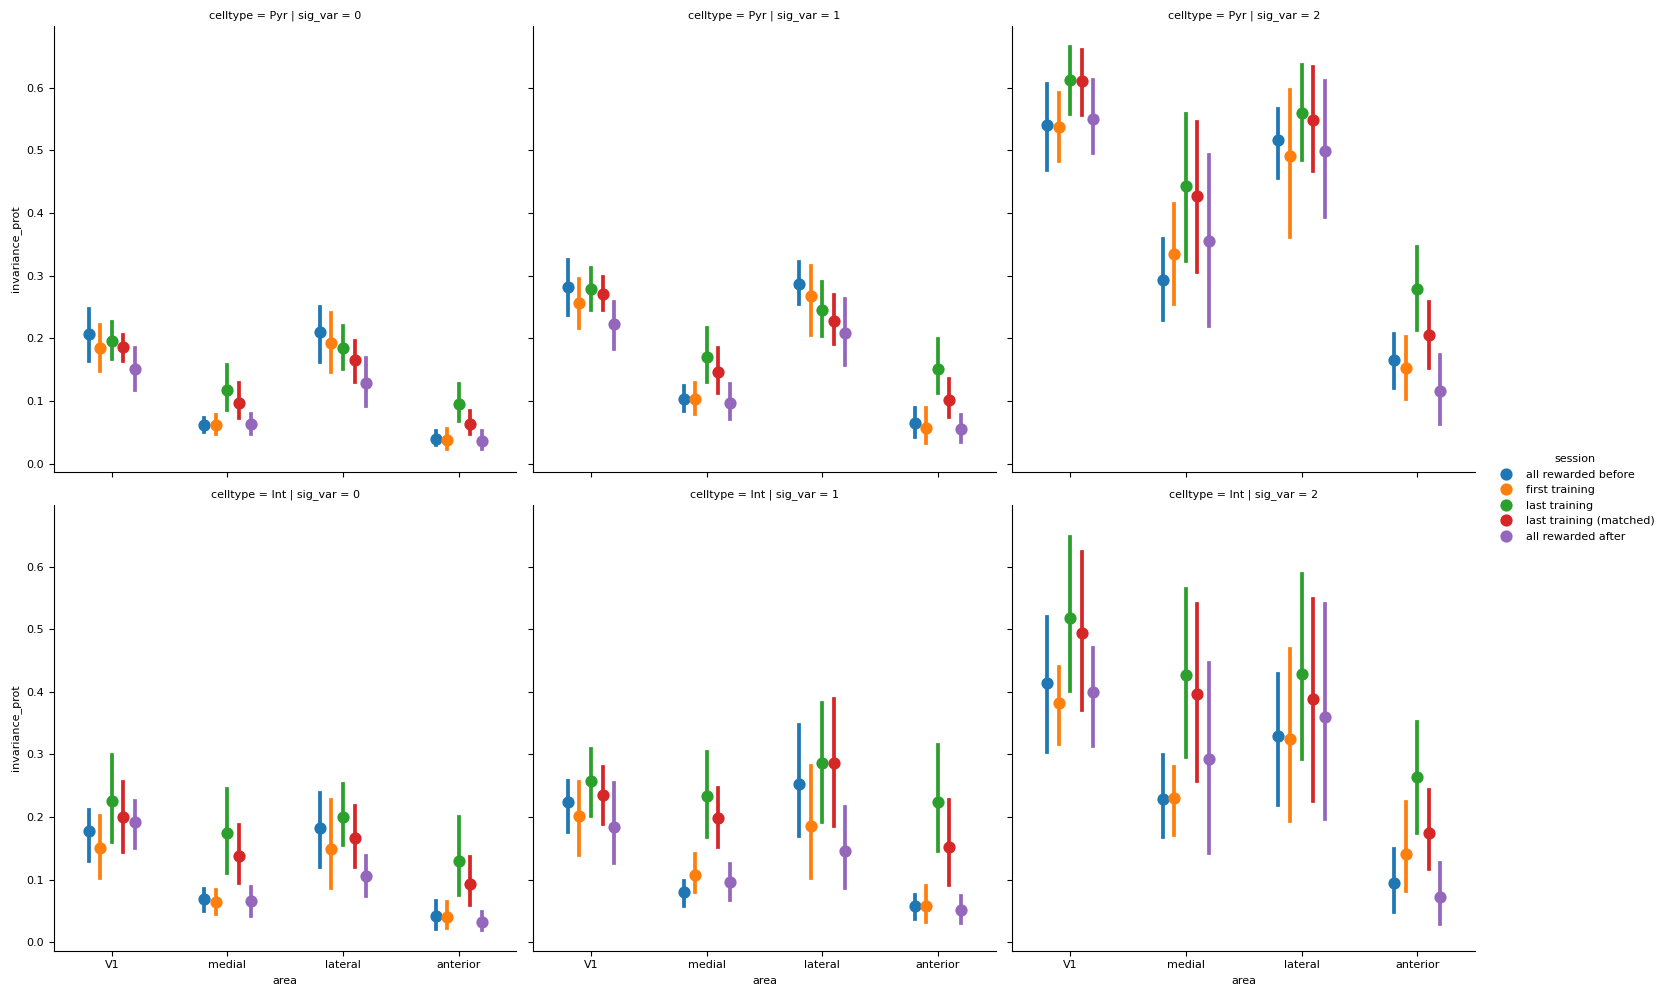

In [152]:
sns.catplot(data=df_iindex_trial_bybins, x="area", y="invariance_prot", hue="session", row="celltype", col="sig_var", kind="point", linestyle="none", dodge=.4)

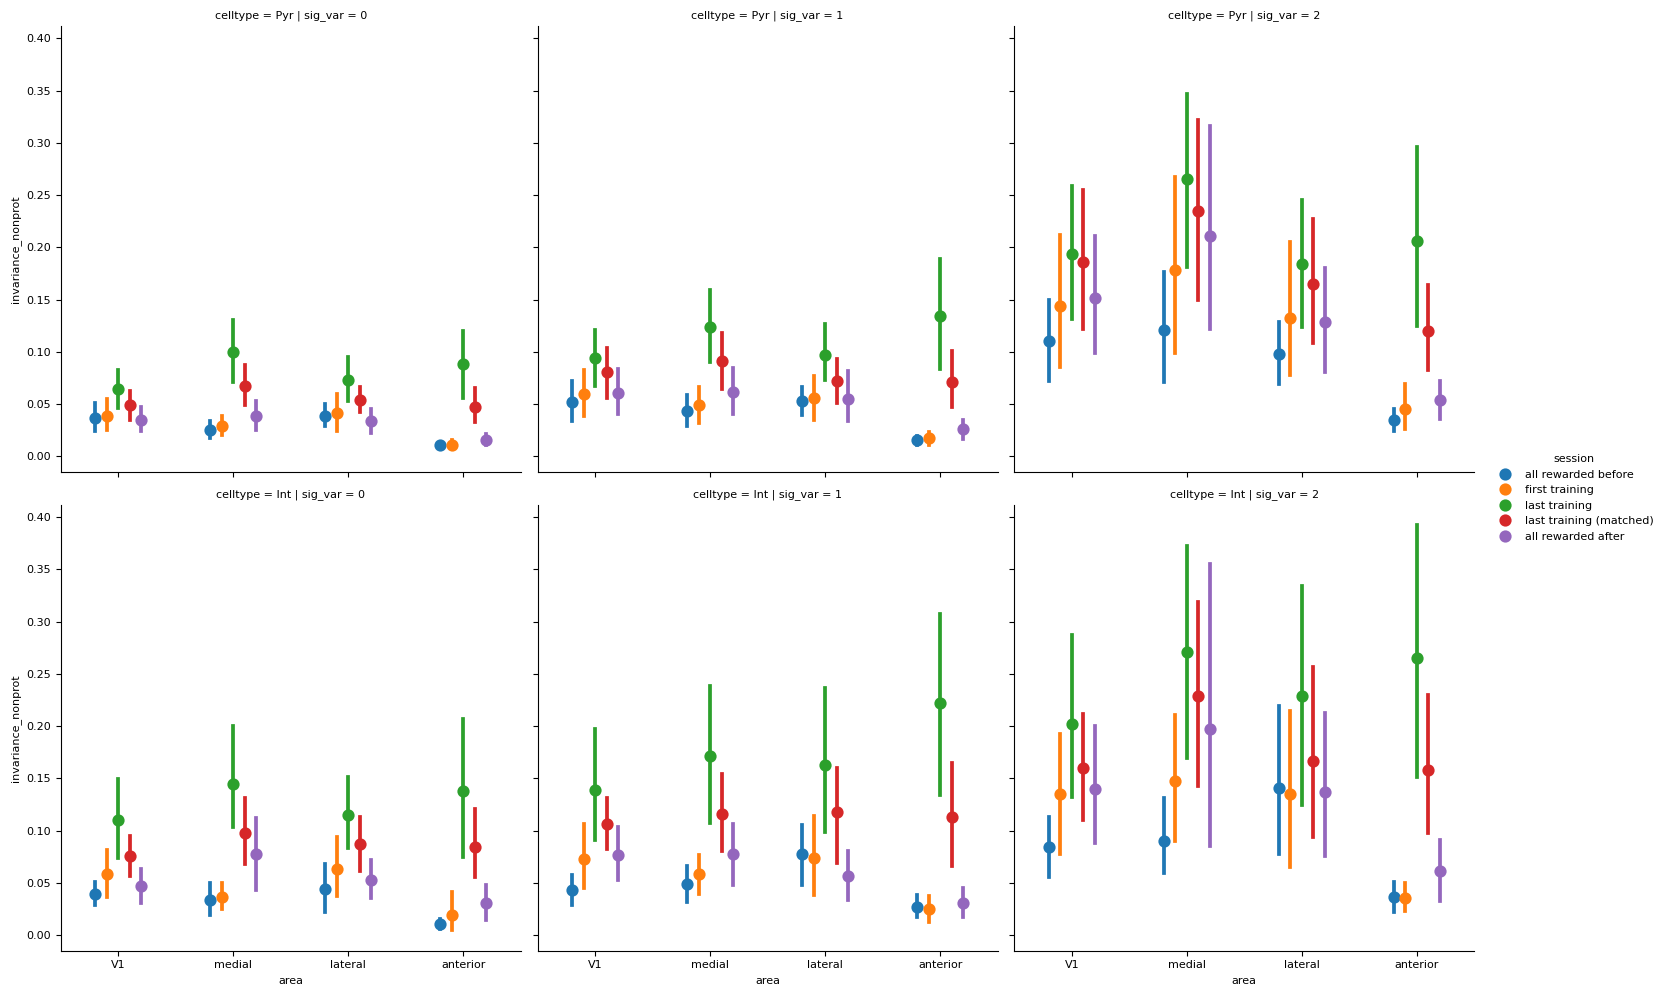

In [153]:
sns.catplot(data=df_iindex_trial_bybins, x="area", y="invariance_nonprot", hue="session", row="celltype", col="sig_var", kind="point", linestyle="none", dodge=.4)

# RSM by dprime on prototypes

In [169]:
def dprime_cell(response, condition1, condition2, discrimination_region=(0,125), subpop=None):
    """
    Compute the d-prime for a single cell.
    """
    response = response[:,:,discrimination_region[0]:discrimination_region[1]].mean(2)
    r1 = response[:, condition1]
    r2 = response[:, condition2]
    if subpop is not None:
        r1 = r1[subpop]
        r2 = r2[subpop]
    # collect means and stds
    mu1 = r1.mean(1)
    mu2 = r2.mean(1)
    std1 = r1.std(1) + np.finfo(np.float64).tiny
    std2 = r2.std(1) + np.finfo(np.float64).tiny
    #compute the train dprime
    dp = 2 * ((mu1 - mu2) / (std1 + std2))
    return dp

def select_neurons(m1, area: str, celltype:str, dprime = None, dptsh=95):
    ia = utils.get_region_idx(m1.iarea, area)
    assert celltype in ['Pyr', 'Int'], "celltype must be either 'Pyr' or 'Int'"
    selected_type = np.logical_not(m1.isred[:,0]).astype(bool) if celltype == 'Pyr' else m1.isred[:,0].astype(bool)
    if dprime is None:
        pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(m1.train_dp[ia*selected_type], tsh=dptsh) #tresh based on the area
    else:
        pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dprime[ia*selected_type], tsh=dptsh)
    prefer_r = (m1.train_dp>=pstv_tsh)
    prefer_nr = (m1.train_dp<=ngtv_tsh)
    area_prefer_r = prefer_r * ia * selected_type
    area_prefer_nr = prefer_nr * ia * selected_type
    return area_prefer_r, area_prefer_nr, selected_type, ia

In [161]:
def get_sig_neurons_dp(m, dp, area: str, celltype: str) -> np.ndarray:
    a_prefer, b_prefer, _ , _ = select_neurons(m, area, celltype, dprime=dp, dptsh=.5) #fixed tresh for dprime
    # ensure column exists (zero-based, as created above)
    selection = a_prefer + b_prefer # select both preferring neurons
    if 'stim_id_matrix' not in m.frameselector.columns:
        mask_B = m.frameselector['trial_type'].isin(['non rewarded', 'non rewarded test'])
        base = m.frameselector['istim'].astype('Int64') - 1  # zero-based
        m.frameselector['stim_id_matrix'] =np.where(~mask_B, base, base + 51)
    per_trial_resp = m.interp_spks[:, :, :100].mean(2)  # (neurons, trials)
    # per-trial response over first 100 positions
    sig_neurons = per_trial_resp[selection, :]  # filter neurons
    nneurons = sig_neurons.shape[0]
    sig_neurons = zscore(sig_neurons, axis=1, nan_policy='omit') #across textures
    return sig_neurons, nneurons

In [170]:
rows = []
cbin = 3 # each bin is cummaltive of :25 , bin
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        mask_B = m.frameselector['trial_type'].isin(['non rewarded', 'non rewarded test'])
        base = m.frameselector['istim'].astype('Int64') - 1  # zero-based
        m.frameselector['stim_id_matrix'] = np.where(~mask_B, base, base + 51)
        ntrials = m.interp_spks.shape[1]
        save_pth = obj_path.joinpath(name,datexp,blk)
        rsm_m_dp = np.empty((ntrials, ntrials, nareas, ncelltypes))
        if sess == 'last training (matched)':
            probs = np.load(save_pth.joinpath("probs.npy"), allow_pickle=True)
            protA, protB, restA, restB = m.trial_dict["rewarded"], m.trial_dict["non rewarded"], m.trial_dict["rewarded test"], m.trial_dict["non rewarded test"]
            prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
            rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
            m_rew = np.concatenate(prot_matched_trials[:,0]).astype(int)
            m_nrew = np.concatenate(prot_matched_trials[:,1]).astype(int)
            m_rew_test = np.concatenate(rest_matched_trials[:,0]).astype(int)
            m_nrew_test = np.concatenate(rest_matched_trials[:,1]).astype(int)
        else:
            m_rew, m_nrew, m_rew_test, m_nrew_test = m.trial_dict["rewarded"], m.trial_dict["non rewarded"], m.trial_dict["rewarded test"], m.trial_dict["non rewarded test"]
        dp = dprime_cell(m.interp_spks, m_rew, m_nrew, discrimination_region=(0,100))
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                print(f"Processing area: {area}, celltype: {ctype}")
                sig_neurons, nneurons = get_sig_neurons_dp(m, dp, area, ctype)
                rsm_matrix = rsm.get_rsm_trial(sig_neurons)
                trials_per_stim = rsm.get_trials_per_stim(m)
                rsm_cleaned = rsm.clean_rsm_trial(rsm_matrix, sig_neurons, trials_per_stim)
                rsm_m_dp[:,:,ia,ic] = rsm_cleaned
                filtered_rsm_nonprot = rsm.filter_rsm(rsm_m_dp[:,:,ia,ic], m_rew_test, m_nrew_test)
                intraA_nonprot, intraB_nonprot, intercat_nonprot = rsm.compute_iindex_cond(filtered_rsm_nonprot, m_rew_test)
                rows.append({
                    "mouse": name,
                    "session": sess,
                    "area": area,
                    "celltype": ctype,
                    "IntraA_nonprot": intraA_nonprot,
                    "IntraB_nonprot": intraB_nonprot,
                    "InterCat_nonprot": intercat_nonprot
                })
        np.save(save_pth.joinpath("trial_trial_rsm_dp.npy"), rsm_m_dp)
    clear_output(wait=True)
df_iindex_trial_dp = pd.DataFrame(rows)
df_iindex_trial_dp.to_csv(obj_path.joinpath("overall","trial_trial_rsm_summary_dp.csv"), index=False)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Processing area: V1, celltype: Pyr
Processing area: V1, celltype: Int
Processing area: medial, celltype: Pyr
Processing area: medial, celltype: Int
Processing area: lateral, celltype: Pyr
Processing area: lateral, celltype: Int
Processing area: anterior, celltype: Pyr
Processing area: anterior, celltype: Int
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_va

C:\Users\labadmin\AppData\Local\Temp\ipykernel_40788\2883470419.py:13: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sig_neurons = zscore(sig_neurons, axis=1, nan_policy='omit') #across textures
C:\Users\labadmin\Documents\category-neural\src\rsm.py:174: RuntimeWarning: Mean of empty slice
  intraA = np.nanmean(rsm_filtered[:len(cond1), :len(cond1)])
C:\Users\labadmin\Documents\category-neural\src\rsm.py:175: RuntimeWarning: Mean of empty slice
  intraB = np.nanmean(rsm_filtered[len(cond1):, len(cond1):])
C:\Users\labadmin\Documents\category-neural\src\rsm.py:176: RuntimeWarning: Mean of empty slice
  intercat = np.nanmean(rsm_filtered[:len(cond1), len(cond1):])


Processing area: lateral, celltype: Int
Processing area: anterior, celltype: Pyr
Processing area: anterior, celltype: Int
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG15\2024_11_01\3
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Processing area: V1, celltype: Pyr
Processing area: V1, celltype: Int
Processing area: medial, celltype: Pyr
Processing area: medial, celltype: Int
Processing area: lateral, celltype: Pyr
Processing area: lateral, celltype: Int
Processing area: anterior, celltype: Pyr
Processing area: anterior, celltype: Int


c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\labadmin\Documents\category-neural\src\rsm.py:174: RuntimeWarning: Mean of empty slice
  intraA = np.nanmean(rsm_filtered[:len(cond1), :len(cond1)])
C:\Users\labadmin\Documents\category-neural\src\rsm.py:175: RuntimeWarning: Mean of empty slice
  intraB = np.nanmean(rsm_filtered[len(cond1):, len(cond1):])
C:\Users\labadmin\Documents\category-neural\src\rsm.py:176: RuntimeWarning: Mean of empty slice
  int

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG21\2025_07_18\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Processing area: V1, celltype: Pyr
Processing area: V1, celltype: Int
Processing area: medial, celltype: Pyr
Processing area: medial, celltype: Int
Processing area: lateral, celltype: Pyr
Processing area: lateral, celltype: Int
Processing area: anterior, celltype: Pyr
Processing area: anterior, celltype: Int
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG21\2025_08_08\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps',

In [171]:
df_iindex_trial_dp = df_iindex_trial_dp.assign(invariance_nonprot = np.mean([df_iindex_trial_dp['IntraA_nonprot'], df_iindex_trial_dp['IntraB_nonprot']], axis=0) - df_iindex_trial_dp['InterCat_nonprot'])
df_iindex_trial_dp.to_csv(obj_path.joinpath("overall","trial_trial_rsm_summary_dp.csv"), index=False)

In [176]:
# find where are the nan 
df_iindex_trial_dp[df_iindex_trial_dp.isna().any(axis=1)]

,mouse,session,area,celltype,IntraA_nonprot,IntraB_nonprot,InterCat_nonprot,invariance_nonprot
55,VG24,all rewarded before,anterior,Int,NaN,NaN,NaN,NaN
340,VG14,all rewarded after,lateral,Pyr,NaN,NaN,NaN,NaN
351,VG15,all rewarded after,anterior,Int,NaN,NaN,NaN,NaN


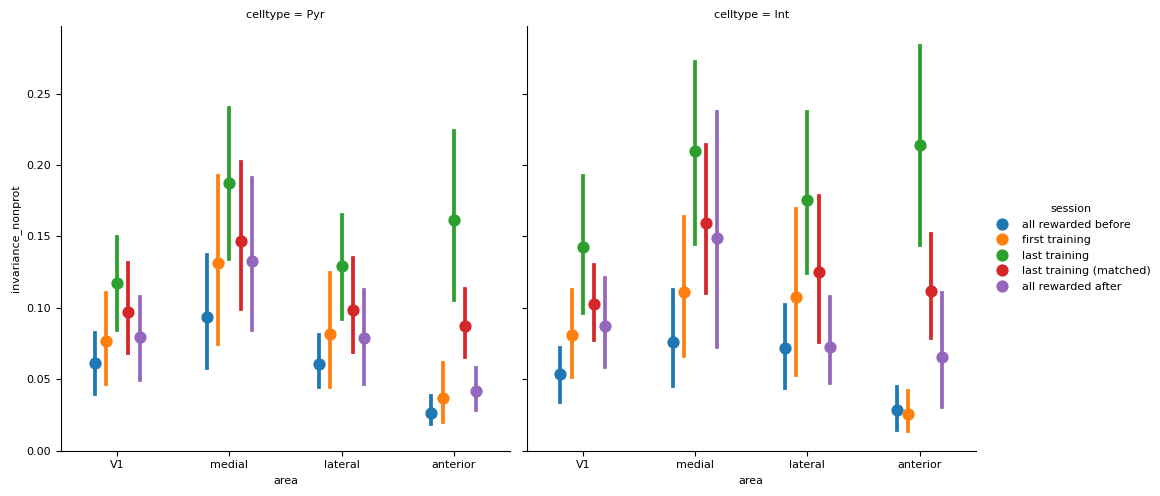

In [172]:
sns.catplot(data=df_iindex_trial_dp, x="area", y="invariance_nonprot", hue="session", col="celltype", kind="point", linestyle="none", dodge=.4)